In [1]:
"""
https://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit

To drop: numwrk, totwag, unempdur
Fillna: immigr (3.0), disabl (0.0), 
Filter nan rows: mart_d, yeduc
"""

'\nhttps://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit\n\nTo drop: numwrk, totwag, unempdur\nFillna: immigr (3.0), disabl (0.0), \nFilter nan rows: mart_d, yeduc\n'

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
import catboost

from tqdm.auto import tqdm
from pathlib import Path

In [3]:
src_dir = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/Tiaravanni Hermawan's files - Egypt/04_Data/2026_data/"
)
excel_path = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/Tiaravanni Hermawan's files - Egypt_ERF_data/data_correlation.xlsx"
)

In [4]:
survey_df = pd.read_csv(src_dir.parent / "Result/ind_survey_data_gov_assigned.csv")
distribution_df = pd.read_csv(
    src_dir.parent / "Result/population_density_matrix.csv", index_col="NAME1_"
)
masking_df = pd.read_excel(
    src_dir.parent / "Result/correlation.xlsx", sheet_name="Sheet1"
)
excel_df = pd.read_excel(excel_path, sheet_name="command_unit")

In [5]:
female_df = survey_df[survey_df['sex_label'] == 'Female']
male_df = survey_df[survey_df['sex_label'] == 'Male']

In [6]:
governorates = survey_df[survey_df["NAME1_"].notna()]["NAME1_"].unique()

rng = np.random.default_rng(seed=42)
sample_df = survey_df.copy(deep=True)
sample_df["command_unit"] = None
command_units = distribution_df.columns

gov_indices = {
    gov: idx.to_numpy() for gov, idx in survey_df.groupby("NAME1_").groups.items()
}
female_gov_indices = {
    gov: idx.to_numpy() for gov, idx in female_df.groupby("NAME1_").groups.items()
}
male_gov_indices = {
    gov: idx.to_numpy() for gov, idx in male_df.groupby("NAME1_").groups.items()
}

for gov, idx in gov_indices.items():
    probs = distribution_df.loc[gov].to_numpy()

    assignments = rng.choice(
        command_units,
        size=len(idx),
        p=probs,
    )

    sample_df.loc[idx, "command_unit"] = assignments

sample_df.loc[sample_df["command_unit"] == "other", "command_unit"] = None

sample_df = sample_df[sample_df["command_unit"].notna()]
final_sample = sample_df.merge(
    excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
)

to_correlate = masking_df.loc[masking_df["correl"] == 1, "variable"]
final_sample = final_sample.dropna(subset=['mart_d', 'yeduc'])
final_sample['hrswksc'] = final_sample['hrswksc'].fillna(0)
final_sample['hrswk'] = final_sample['hrswk'] + final_sample['hrswksc']

final_sample['immigr'] = final_sample['immigr'].fillna(3)
final_sample['disabl'] = final_sample['disabl'].fillna(0)

final_sample = final_sample.drop(columns=['unempdur', 'numwrk', 'totwag'])
cols = [c for c in to_correlate if c in final_sample.columns]

In [7]:
categorical_columns = masking_df[(masking_df["type"] == 'binary') | (masking_df["type"] == 'categorical') & (masking_df["variable"].isin(cols))]['variable'].values.tolist()
final_sample[categorical_columns] = final_sample[categorical_columns].astype(str)

In [8]:
model = catboost.CatBoostRegressor()
model.fit(X=final_sample[cols].drop(columns=['hrswk', 'hrswksc']), y=final_sample['hrswk'], cat_features=categorical_columns)

Learning rate set to 0.060431
0:	learn: 12.7470502	total: 63.9ms	remaining: 1m 3s
1:	learn: 12.5791166	total: 70.3ms	remaining: 35.1s
2:	learn: 12.4238709	total: 76.4ms	remaining: 25.4s
3:	learn: 12.2733327	total: 81.7ms	remaining: 20.3s
4:	learn: 12.1394401	total: 87.5ms	remaining: 17.4s
5:	learn: 12.0224380	total: 92.5ms	remaining: 15.3s
6:	learn: 11.9166643	total: 97.3ms	remaining: 13.8s
7:	learn: 11.8222820	total: 102ms	remaining: 12.7s
8:	learn: 11.7272970	total: 106ms	remaining: 11.7s
9:	learn: 11.6490782	total: 110ms	remaining: 10.9s
10:	learn: 11.5771619	total: 114ms	remaining: 10.3s
11:	learn: 11.5059573	total: 118ms	remaining: 9.7s
12:	learn: 11.4453039	total: 122ms	remaining: 9.27s
13:	learn: 11.3912050	total: 126ms	remaining: 8.88s
14:	learn: 11.3366789	total: 131ms	remaining: 8.59s
15:	learn: 11.2923471	total: 135ms	remaining: 8.28s
16:	learn: 11.2470797	total: 138ms	remaining: 7.98s
17:	learn: 11.1867973	total: 142ms	remaining: 7.74s
18:	learn: 11.1482052	total: 146ms	rem

CatBoostRegressor(loss_function='RMSE')

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from catboost import CatBoostRegressor

final_sample_female = final_sample[final_sample['sex'] == '2']

X = final_sample_female[cols].drop(columns=["hrswk", "hrswksc"])
y = final_sample_female["hrswk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100,
)

model.fit(
    X_train,
    y_train,
    cat_features=categorical_columns,
)

# predictions on unseen data
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

0:	learn: 11.6504468	total: 3.2ms	remaining: 6.4s
100:	learn: 9.4209056	total: 272ms	remaining: 5.12s
200:	learn: 8.7852024	total: 530ms	remaining: 4.74s
300:	learn: 8.2800136	total: 788ms	remaining: 4.45s
400:	learn: 7.6305033	total: 1.06s	remaining: 4.24s
500:	learn: 7.1382038	total: 1.33s	remaining: 3.99s
600:	learn: 6.7177071	total: 1.59s	remaining: 3.71s
700:	learn: 6.3599994	total: 1.86s	remaining: 3.45s
800:	learn: 5.9661659	total: 2.13s	remaining: 3.19s
900:	learn: 5.6176303	total: 2.39s	remaining: 2.92s
1000:	learn: 5.3703475	total: 2.65s	remaining: 2.65s
1100:	learn: 5.1135998	total: 2.92s	remaining: 2.38s
1200:	learn: 4.8866303	total: 3.19s	remaining: 2.12s
1300:	learn: 4.6894428	total: 3.45s	remaining: 1.85s
1400:	learn: 4.5001478	total: 3.71s	remaining: 1.59s
1500:	learn: 4.3119605	total: 3.98s	remaining: 1.32s
1600:	learn: 4.1302745	total: 4.26s	remaining: 1.06s
1700:	learn: 3.9674771	total: 4.52s	remaining: 795ms
1800:	learn: 3.8082949	total: 4.79s	remaining: 530ms
1900:

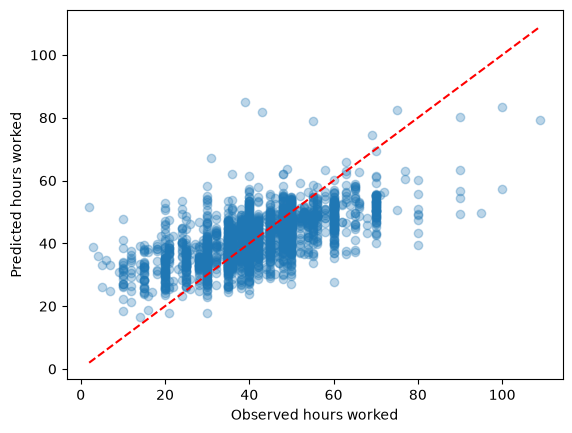

In [11]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)
plt.xlabel("Observed hours worked")
plt.ylabel("Predicted hours worked")
plt.show()

In [12]:
imp = (
    pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )
    .sort_values(ascending=False)
)

print(imp.head(20))

sex                                 10.801042
tenure                               9.756309
female_unemployment_rate             7.893348
age                                  7.311927
emps                                 6.604669
female_healthcare_decision           5.176162
secjob                               5.055295
empstab                              4.753105
female_contraceptives_decision       3.501975
female_violence_emotional            3.494575
command_unit                         2.916987
yeduc                                2.535462
female_violence_physical             2.420248
household_size                       1.939159
socsec                               1.832459
n_other_employed                     1.695213
female_child_married                 1.589085
female_labour_participation_rate     1.570546
female_circumcised                   1.544094
mart_d                               1.194229
dtype: float64


In [13]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print(r2_score(y_test, y_pred_base))

-0.0003372369011436227


In [14]:
from sklearn.metrics import r2_score

print("Train R²:", r2_score(y_train, model.predict(X_train)))
print("Test R² :", r2_score(y_test, y_pred))

Train R²: 0.5128466617481675
Test R² : 0.410414401946423


<Axes: >

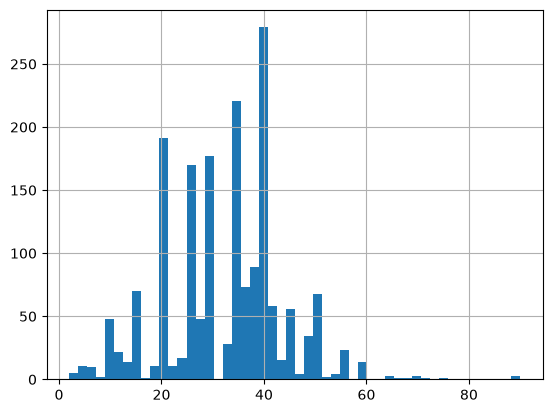

In [26]:
final_sample_female["hrswk"].hist(bins=50)